In [23]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "llama3"

# 1. Cargar datos

In [3]:
df = pd.read_csv(r"C:\Users\Mate\OneDrive\Documents\2.Master\1. Andes\7. Ciclo7\Desarrollo de soluciones\proyecto de grado\consolidado\consolidado_v2.csv")

df_train = df[df["dataset_type"] == "TRAIN_TEST"]
df_test  = df[df["dataset_type"] == "EVAL"]

# 2. Construir ejemplos (few-shot)

In [4]:
def build_examples(df, n=5):
    samples = df.sample(n)
    examples = ""

    for _, row in samples.iterrows():
        examples += f"""
Text: {row['text']}
Label: {row['label']}
"""
    return examples

# 3. Clasificador

In [5]:
def classify_text(text, examples):

    prompt = f"""
Eres un experto en la clasificación de secciones de artículos científicos.

Etiquetas:
-INTRO: Introducción que presenta el problema de investigación, su motivación, los objetivos
del trabajo.
-BACK: Antecedente que describe el estado del arte, trabajos previos
relevantes y el contexto teórico. 
-METH: Metodología que explica el diseño experimental, los métodos, modelos, datos.
-RES: Resultados donde se Presenta los resultados obtenidos a partir de los experimentos, análisis
empíricos o evaluaciones realizadas.
-DISC: Discusión donde se Interpreta los resultados, analiza sus implicaciones, los compara con
trabajos previos. 
-CONTR: Contribuciones donde se  Identifica explícitamente los aportes del trabajo, tales como
métodos propuestos, hallazgos principales o avances conceptuales.
-LIM: Limitaciones donde se Describe restricciones del enfoque, supuestos adoptados, posibles
fuentes de error.
-CONC: Conlusiones donde se Resume los principales hallazgos del trabajo y presenta líneas de
trabajo futuro.

Reglas:
- Retorna unicamente una etiqueta
- No son necesarias explicaciones
- Sé preciso

Ejemplos:
{examples}

Ahora clasifica:

Texto: {text}
Etiqueta:
"""

    response = requests.post(
        OLLAMA_URL,
        json={
            "model": MODEL,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0.1,   # 🔑 clave para estabilidad
                "top_p": 0.9
            }
        }
    )

    return response.json()["response"].strip()


In [9]:
examples = """
Text: En los últimos años, el crecimiento acelerado de los modelos de aprendizaje automático ha transformado múltiples industrias, desde la salud hasta las finanzas. En particular, los modelos de lenguaje natural han demostrado una notable capacidad para comprender y generar texto con alta coherencia. El presente trabajo tiene como objetivo desarrollar un sistema capaz de identificar automáticamente las diferentes secciones de un documento, facilitando así tareas de análisis, clasificación y procesamiento de información. Para ello, se emplean técnicas de procesamiento de lenguaje natural junto con modelos de aprendizaje supervisado. Este documento se estructura de la siguiente manera: en primer lugar, se presenta el marco teórico; posteriormente, se describe la metodología utilizada; luego, se analizan los resultados obtenidos; y finalmente, se exponen las conclusiones del estudio.
Label: INTRO

Text: Para el desarrollo del sistema de reconocimiento de secciones, se implementó un enfoque basado en aprendizaje supervisado utilizando modelos de lenguaje preentrenados. En primer lugar, se recopiló un conjunto de datos compuesto por documentos estructurados, los cuales fueron anotados manualmente para identificar las diferentes secciones. Posteriormente, se realizó un proceso de preprocesamiento de texto que incluyó la normalización, eliminación de caracteres especiales y tokenización. A continuación, los textos fueron transformados en representaciones numéricas mediante técnicas de vectorización basadas en embeddings. El modelo fue entrenado utilizando un esquema de validación cruzada, optimizando los hiperparámetros mediante búsqueda aleatoria. Finalmente, se evaluó el desempeño del modelo utilizando métricas como precisión, recall y F1-score.   
Label: METH

Text: El modelo propuesto alcanzó una precisión del 92.3%, un recall de 90.1% y un F1-score de 91.2% sobre el conjunto de prueba. Estos resultados superan a los modelos base, los cuales obtuvieron un F1-score promedio de 85.6%. Adicionalmente, se observó que el modelo presenta un mejor desempeño en la identificación de secciones como "introducción" y "metodología", mientras que muestra ligeras dificultades en la clasificación de secciones más cortas como "conclusiones". En términos de tiempo de entrenamiento, el modelo requirió aproximadamente
Label: RES

Text: Diversos estudios han abordado el problema de la clasificación de texto utilizando enfoques basados en aprendizaje automático. Inicialmente, los métodos tradicionales como Naive Bayes y Support Vector Machines fueron ampliamente utilizados debido a su eficiencia y facilidad de implementación. Con el avance de las técnicas de aprendizaje profundo, los modelos basados en redes neuronales comenzaron a mostrar mejoras significativas en tareas de procesamiento de lenguaje natural. En particular, los modelos de transformers han revolucionado el campo al permitir capturar dependencias de largo alcance en el texto. Investigaciones recientes han explorado el uso de modelos preentrenados para tareas específicas como la clasificación de secciones en documentos, logrando resultados superiores en comparación con enfoques tradicionales. Sin embargo, aún existen desafíos relacionados con la generalización y la disponibilidad de datos etiquetados.  
Label: BACK

Text: Los resultados obtenidos indican que el modelo basado en transformers presenta un mejor desempeño en comparación con los enfoques tradicionales. Esta mejora puede atribuirse a su capacidad para capturar dependencias contextuales más complejas dentro del texto. Sin embargo, se observa que el modelo presenta dificultades en la clasificación de secciones con menor cantidad de datos, lo cual sugiere una posible dependencia de la distribución del conjunto de entrenamiento. Este comportamiento es consistente con lo reportado en trabajos previos. Asimismo, aunque el modelo alcanza altos niveles de precisión, su costo computacional es significativamente mayor, lo que podría limitar su aplicabilidad en entornos con recursos restringidos. Por tanto, existe un compromiso entre desempeño y eficiencia que debe ser considerado. 
Label: DISC

Text: El presente trabajo realiza las siguientes contribuciones principales:
1. Se propone un modelo basado en transformers para la clasificación automática de secciones en documentos estructurados.
2. Se construye un conjunto de datos anotado manualmente que permite entrenar y evaluar modelos de clasificación de texto en este dominio.
3. Se desarrolla un pipeline de procesamiento de lenguaje natural que integra técnicas de preprocesamiento, vectorización y reducción de dimensionalidad.
4. Se realiza una evaluación comparativa entre enfoques tradicionales y modelos basados en aprendizaje profundo, evidenciando mejoras significativas en el desempeño.
Estas contribuciones buscan avanzar en el estado del arte en la clasificación automática de documentos.
Label: CONT

Text: A pesar de los resultados obtenidos, este estudio presenta varias limitaciones que deben ser consideradas. En primer lugar, el tamaño del conjunto de datos es relativamente reducido, lo que podría afectar la capacidad de generalización del modelo a otros dominios. Asimismo, el proceso de anotación fue realizado manualmente, lo que introduce la posibilidad de sesgos subjetivos en la clasificación de las secciones. Adicionalmente, el modelo fue evaluado únicamente en un tipo específico de documentos, por lo que su desempeño en otros contextos no ha sido validado. Finalmente, el alto costo computacional del modelo limita su aplicabilidad en entornos con recursos restringidos, lo que representa una barrera para su implementación a gran escala.
Label: LIM

Text: En este trabajo se desarrolló un modelo para la clasificación automática de secciones en documentos, logrando un desempeño superior en comparación con enfoques tradicionales. Los resultados obtenidos demuestran que el uso de modelos basados en transformers permite capturar de manera más efectiva la estructura semántica del texto. Asimismo, se evidenció que la calidad y el tamaño del conjunto de datos influyen significativamente en el rendimiento del modelo. A pesar de las limitaciones identificadas, el enfoque propuesto constituye una alternativa sólida para tareas de procesamiento de lenguaje natural. Como trabajo futuro, se propone explorar técnicas de aumento de datos y optimización de hiperparámetros con el fin de mejorar la generalización del modelo en distintos dominios. 
Label: CONC
"""

In [14]:
df_sample = df_train.groupby("label", group_keys=False).sample(
    n=40,
    random_state=42
)

In [16]:
df_sample

,doc_id,filename,text,label,dataset_type
5717,460447,41009095.txt,departamento de junin en la provincia de mendo...,BACK,TRAIN_TEST
3824,427432,160189086.txt,la mineria es una industria que puede generar...,BACK,TRAIN_TEST
5329,155228,158655554.txt,revpsirevistadepsicologia 1261402023issn2422 5...,BACK,TRAIN_TEST
5589,352451,140155313.txt,causa de lesion medular son las caidas 2la les...,BACK,TRAIN_TEST
5821,527370,127958829.txt,acuerdo a las estadisticas de la ocde 2021 des...,BACK,TRAIN_TEST
...,...,...,...,...,...
17802,31857,25379404.txt,of this study and the altitudinal range of the...,RES,TRAIN_TEST
17777,11947,25373364.txt,CVRS evaluada con los cuestionarios SF en estu...,RES,TRAIN_TEST
16250,5390,171791665.txt,"os Humanos, conferencia publicada en Revista d...",RES,TRAIN_TEST
17784,13200,25375467.txt,de este origen -burgu����s es decir2. La Ilust...,RES,TRAIN_TEST


In [17]:
y_true = []
y_pred = []

for _, row in df_sample.iterrows():
    pred = classify_text(row["text"], examples)

    y_true.append(row["label"])
    y_pred.append(pred)

    print(f"REAL: {row['label']} | PRED: {pred}")

REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: BACK
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: RES
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: BACK
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: METH
REAL: BACK | PRED: Label: BACK
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: RES
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Label: CONTR
REAL: BACK | PRED: Label: INTRO
REAL: BACK | PRED: Labe

In [19]:
# Accuracy
acc = accuracy_score(y_true, y_pred)

# F1 (macro es clave cuando tienes clases balanceadas)
f1_macro = f1_score(y_true, y_pred, average="macro")

# F1 ponderado (por si hay desbalance)
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"F1 (macro): {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")

Accuracy: 0.0625
F1 (macro): 0.0316
F1 (weighted): 0.0908


In [22]:
labels = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR","LIM","CONC"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

print(cm)

[[11  4  1  0  1  0  4  0]
 [ 0  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  3  0]
 [ 0  3  0  1  0  0  5  0]
 [ 0  0  0  0  0  0  4  0]
 [ 0  2  0  0  0  0  4  0]
 [ 0  1  1  0  0  0  6  0]
 [ 1  2  0  1  1  0  5  1]]


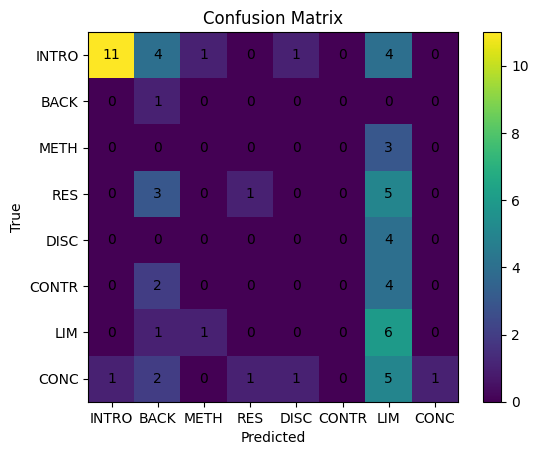

In [24]:
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()